# 🐾 Multi-Animal Classification using CNN (MobileNetV2)

This project classifies images into multiple animal categories using Deep Learning.

### 📌 Classes:
butterfly, cat, chicken, cow, dog, elephant, horse, sheep, spider, squirrel

# Step 1: Import Libraries

- tensorflow → deep learning engine
- keras → model building (layers, models)
- numpy → numerical operations
- sklearn → class imbalance handling
- preprocess_input → MobileNetV2 preprocessing

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Step 2: Load Dataset

- image_dataset_from_directory → loads images from folder automatically
- folder names → become labels (automatic labeling)
- validation_split → splits data into training and validation sets
- image_size → resizes all images to same size
- batch_size → number of images processed at once

👉 Output:
- train_data → used for training the model
- val_data → used for validation/testing

In [4]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/raw-img",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(150,150),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/raw-img",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(150,150),
    batch_size=32
)

# check class names
class_names = train_data.class_names
print("Classes:", class_names)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Classes: ['butterfly', 'cat', 'chiken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


# Step 3: Check Class Distribution

- Before fixing imbalance, we must check it
- Count how many samples each class has
- This helps us decide:
    → Is dataset balanced?
    → Do we need class_weight or not?

👉 Good Practice:
Never assume imbalance — always verify

In [6]:
import numpy as np

labels = []

# collect labels
for _, y in train_data:
    labels.extend(y.numpy())

labels = np.array(labels)

# count each class
unique, counts = np.unique(labels, return_counts=True)

print("Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u} ({class_names[u]}): {c}")

Class Distribution:
Class 0 (butterfly): 1723
Class 1 (cat): 1345
Class 2 (chiken): 2476
Class 3 (cow): 1484
Class 4 (dog): 3915
Class 5 (elephant): 1152
Class 6 (horse): 2087
Class 7 (sheep): 1438
Class 8 (spider): 3842
Class 9 (squirrel): 1482


# Step 4: Handle Class Imbalance (After Verification)

- Dataset is imbalanced (ratio > 3)
- Some classes have many samples, others have fewer

👉 Solution:
- Use class_weight
- Increase importance of minority classes
- Reduce importance of majority classes

👉 This helps:
- Balanced learning
- Better performance across all classes

In [7]:
from sklearn.utils import class_weight
import numpy as np

# compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.2155542658154381), 1: np.float64(1.557174721189591), 2: np.float64(0.8458804523424879), 3: np.float64(1.411320754716981), 4: np.float64(0.5349680715197956), 5: np.float64(1.8180555555555555), 6: np.float64(1.0035457594633446), 7: np.float64(1.4564673157162726), 8: np.float64(0.5451327433628319), 9: np.float64(1.413225371120108)}


# Step 5: Data Preprocessing (MobileNetV2)

- Deep learning models require properly scaled input
- MobileNetV2 expects pixel values in range [-1, +1]

👉 Why preprocessing?
- Raw images → values 0–255
- Model trained on normalized data

👉 preprocess_input:
- Converts pixel range from [0,255] → [-1,1]
- Matches MobileNetV2 training

👉 Important:
Use SAME preprocessing during training and prediction

In [8]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_data = train_data.map(lambda x, y: (preprocess_input(x), y))
val_data = val_data.map(lambda x, y: (preprocess_input(x), y))

# Step 6: Build Model (MobileNetV2 - Multi-Class)

- We use Transfer Learning
- MobileNetV2 is pre-trained on ImageNet

👉 Why use it?
- Already learned features (edges, shapes, objects)
- Faster training
- Better accuracy

👉 Key Steps:
1. Load base model (without top layer)
2. Freeze base model (do not train it initially)
3. Add custom layers for our dataset
4. Use softmax for multi-class output

In [9]:
from tensorflow.keras.applications import MobileNetV2

# Load pre-trained model
base_model = MobileNetV2(
    input_shape=(150,150,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

# Build custom model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

C:\Users\Tirupati\AppData\Local\Temp\ipykernel_7372\3656936499.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 7: Compile and Train Model

👉 Compile:
- Defines how model learns
- optimizer → how weights are updated
- loss → how error is calculated
- metrics → performance measurement

👉 Train:
- Model learns from data
- Uses class_weight to handle imbalance
- Runs for multiple epochs

👉 Important:
- Multi-class → use softmax + sparse_categorical_crossentropy

In [11]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 280s 419ms/step - accuracy: 0.8554 - loss: 0.4806 - val_accuracy: 0.9263 - val_loss: 0.2314
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 319s 415ms/step - accuracy: 0.9108 - loss: 0.2937 - val_accuracy: 0.9328 - val_loss: 0.2102
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 328s 424ms/step - accuracy: 0.9215 - loss: 0.2549 - val_accuracy: 0.9373 - val_loss: 0.1990
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 316s 415ms/step - accuracy: 0.9278 - loss: 0.2289 - val_accuracy: 0.9358 - val_loss: 0.1961
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 326s 420ms/step - accuracy: 0.9330 - loss: 0.2056 - val_accuracy: 0.9373 - val_loss: 0.1945
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 276s 421ms/step - accuracy: 0.9347 - loss: 0.1941 - val_accuracy: 0.9370 - val_loss: 0.2042
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 283s 433ms/step - accuracy: 0.9411 - loss: 0.1758 - val_accuracy: 0.9383 - val_loss: 0.2124
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 303s 404ms/step - accuracy: 0.9405 -

# Step 8: Model Evaluation (Confusion Matrix)

- Accuracy alone is not enough
- We need detailed performance per class

👉 Confusion Matrix:
- Shows correct and wrong predictions
- Helps identify weak classes

👉 For multi-class:
- Matrix size = N x N (here 10 x 10)

👉 Each row = actual class
👉 Each column = predicted class

In [12]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[368   0   2   0   0   0   0   1  18   0]
 [  0 301   1   0   6   1   1   1   0  12]
 [  2   2 586   1  11   0   1   8   4   7]
 [  0   0   1 336   7   2  13  22   0   1]
 [  1  17   2  10 880   2  16  11   1   8]
 [  0   0   0   3   1 285   2   1   2   0]
 [  0   1   0  17   9  11 482  12   1   3]
 [  0   3   0   9   2   3   3 361   0   1]
 [  9   3   0   1   1   0   2   0 957   6]
 [  2   6   1   0   4   0   0   2   3 362]]


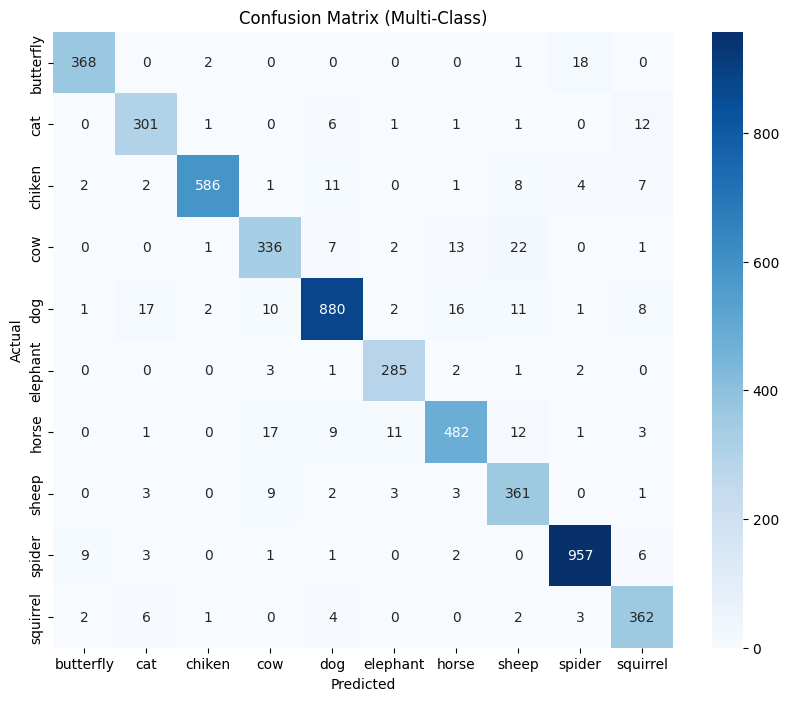

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Multi-Class)")
plt.show()

# Step 9: Classification Report

- Provides detailed performance for each class

👉 Metrics:
- Precision → How many predicted are correct
- Recall → How many actual are detected
- F1-score → Balance of precision and recall

👉 Why important?
- Accuracy alone is not enough
- Shows performance per class
- Helps detect weak classes

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   butterfly       0.96      0.95      0.95       389
         cat       0.90      0.93      0.92       323
      chiken       0.99      0.94      0.96       622
         cow       0.89      0.88      0.89       382
         dog       0.96      0.93      0.94       948
    elephant       0.94      0.97      0.95       294
       horse       0.93      0.90      0.91       536
       sheep       0.86      0.95      0.90       382
      spider       0.97      0.98      0.97       979
    squirrel       0.91      0.95      0.93       380

    accuracy                           0.94      5235
   macro avg       0.93      0.94      0.93      5235
weighted avg       0.94      0.94      0.94      5235



# Step 10: Save Model

- After training, we save the model
- So we can reuse it later without training again

👉 Why important?
- Training takes time
- Saved model can be used for:
    → Prediction
    → API
    → Streamlit app
    → Deployment

👉 File format:
- .h5 (HDF5 format)

In [16]:
model.save("multi_animal_model.h5")

In [17]:
np.save("class_names.npy", class_names)